In [1]:
import sys

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch

from configuration import DIFFUSION_CKPT_PATH, OUTPUT_DIR

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Loading diffusion checkpoint from:', DIFFUSION_CKPT_PATH)


Loading diffusion checkpoint from: ../musdb18/output/diffusion_unet_checkpoint.pt


In [2]:
ckpt    = torch.load(DIFFUSION_CKPT_PATH, map_location='cpu')
history = ckpt['history']

epochs = [h['epoch'] for h in history]
losses = [h['loss']  for h in history]

print(f'Epochs recorded : {len(history)}')
print(f'Initial loss    : {losses[0]:.6f}' if losses else 'No history found')
print(f'Final loss      : {losses[-1]:.6f}' if losses else '')
print(f'Min loss        : {min(losses):.6f}  at epoch {epochs[losses.index(min(losses))]}')
print(f'Max loss        : {max(losses):.6f}  at epoch {epochs[losses.index(max(losses))]}')


Epochs recorded : 600
Initial loss    : 1.022606
Final loss      : 0.116230
Min loss        : 0.103812  at epoch 575
Max loss        : 1.022606  at epoch 1


In [3]:
def ema(values, alpha=0.1):
    smoothed = []
    s = values[0]
    for v in values:
        s = alpha * v + (1 - alpha) * s
        smoothed.append(s)
    return smoothed

losses_smooth = ema(losses, alpha=0.15)


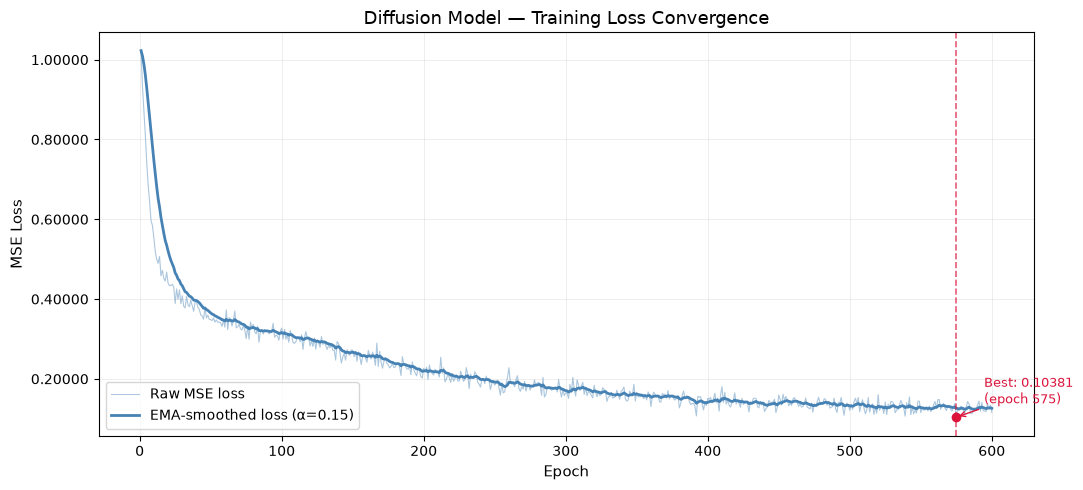

Saved: ../musdb18/output/figures/diffusion_loss_curve.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(epochs, losses, color='steelblue', linewidth=0.8, alpha=0.45, label='Raw MSE loss')
ax.plot(epochs, losses_smooth, color='steelblue', linewidth=2.0, label='EMA-smoothed loss (α=0.15)')

best_idx  = int(np.argmin(losses))
best_ep   = epochs[best_idx]
best_loss = losses[best_idx]
ax.axvline(best_ep, color='crimson', linewidth=1.2, linestyle='--', alpha=0.7)
ax.scatter([best_ep], [best_loss], color='crimson', zorder=5)
ax.annotate(
    f'Best: {best_loss:.5f}\n(epoch {best_ep})',
    xy=(best_ep, best_loss),
    xytext=(20, 10), textcoords='offset points',
    fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0)
)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss', fontsize=11)
ax.set_title('Diffusion Model — Training Loss Convergence', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.5f'))

plt.tight_layout()
out_path = FIGURES_DIR / 'diffusion_loss_curve.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)
